# Project description

Develop a Python-based pricing and risk management application that prices complex autocallable notes (e.g., worst-of Phoenix autocalls linked to a multi-asset equity basket). The engine simulates underlying asset paths using advanced stochastic models (Heston Stochastic Volatility) to properly capture the volatility skew and smile. It evaluates path-dependent early redemption and coupon triggers across discrete observation dates, and outputs accurate prices alongside exact exotic Greeks (Delta, Gamma, Vega, and bucket risks).

### Imports and initialisation

In [1]:
import numpy as np
import scipy.stats as stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from numba import jit, prange
import time

# Configuration for clean plots in Jupyter
import warnings
warnings.filterwarnings('ignore')

print("Environment initialized successfully.")

Environment initialized successfully.


## Environment Setup

This cell initializes the computational environment required for the pricing and risk management engine.

**NumPy** provides the numerical framework used for vectorized calculations and Monte Carlo simulations. **SciPy** supplies statistical functions and probability distributions used throughout the stochastic modeling framework. **Plotly** is used to visualize simulated paths, price distributions, and risk metrics directly within the Jupyter notebook.

**Numba** is imported to accelerate computationally intensive functions through Just-In-Time compilation and parallel execution, which is particularly important when simulating a large number of Monte Carlo paths. The `time` module will be used to benchmark the performance of the different components of the engine.

Finally, warnings are temporarily suppressed to keep the notebook output clean, and a confirmation message verifies that the environment has been successfully initialized.


# Vectorized Path Engine (Stochastic Heston & Cholesky)


In [2]:
@jit(nopython=True, parallel=True)
def simulate_heston_paths_numba(S0, V0, r, q, kappa, theta, xi, rho, T, N_steps, N_paths, L):
    """
    Simulates multi-asset paths under the Heston model with Cholesky correlation.
    S0 : Initial prices (array of size n_assets)
    V0 : Initial variances (array of size n_assets)
    L : Cholesky matrix of the correlation matrix (size 2*n_assets x 2*n_assets or structured)
    """
    n_assets = len(S0)
    dt = T / N_steps
    sqrt_dt = np.sqrt(dt)
    
    # Price storage: 2 * N_paths (for antithetic paths) x (N_steps + 1) x n_assets
    # To simplify the illustration, optimized 2D/3D structure
    # Here we simulate by block for memory
    pass

## Heston Model and Simulation Framework

This function defines the core framework for simulating multi-asset paths under the **Heston stochastic volatility model**. Unlike the Black-Scholes model, where volatility is assumed to be constant, Heston models the instantaneous variance as a stochastic process, allowing the simulation to reproduce important features of equity markets such as volatility clustering and the volatility smile or skew.

For each asset $i$, the Heston dynamics are given by

$$
dS_t^i = (r-q_i)S_t^i\,dt + \sqrt{V_t^i}S_t^i\,dW_t^{S,i},
$$

and

$$
dV_t^i = \kappa_i(\theta_i-V_t^i)\,dt
+ \xi_i\sqrt{V_t^i}\,dW_t^{V,i}.
$$

Here, $S_t^i$ is the asset price and $V_t^i$ its instantaneous variance. The parameters $\kappa$, $\theta$, and $\xi$ respectively control the speed of mean reversion, the long-term variance level, and the volatility of variance. The correlation $\rho$ between the price and variance Brownian motions introduces the leverage effect typically observed in equity markets.

For a multi-asset autocallable, the assets cannot be simulated independently because their returns are correlated. The matrix $L$ is therefore the **Cholesky factor** of the desired correlation matrix, satisfying

$$
LL^\top = \Sigma.
$$

Independent standard normal variables can then be transformed into correlated Gaussian shocks through $L$, allowing the joint dynamics of the underlying basket to be simulated consistently.

In the code, `n_assets` determines the number of underlying assets, while

$$
\Delta t = \frac{T}{N_{\text{steps}}}
$$

defines the time increment used to discretize the continuous-time stochastic differential equations. `sqrt_dt` is precomputed because $\sqrt{\Delta t}$ appears repeatedly when generating Brownian increments, avoiding unnecessary calculations inside the main simulation loop.

The decorator `@jit(nopython=True, parallel=True)` instructs Numba to compile the function into optimized machine code and allows independent simulation paths to be processed in parallel. This is particularly important for an exotic pricing engine because millions of Monte Carlo paths may be required to obtain sufficiently precise prices and Greeks.

The current function is intentionally incomplete: `pass` indicates that the actual discretization of the Heston processes, generation of correlated shocks, and storage of the simulated paths will be implemented next.


In [3]:
def generate_multivariate_heston_paths(S0, V0, r, q, kappa, theta, xi, rho, corr_matrix, T, n_steps, n_paths):
    """
    Generates correlated stochastic price and volatility paths (Heston)
    for a basket of assets with variance reduction using antithetic variables
    and Cholesky matrix stabilization.
    """
    n_assets = len(S0)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    
    n_sims = n_paths // 2
    
    dim = 2 * n_assets
    full_corr = np.eye(dim)
    
    for i in range(n_assets):
        for j in range(n_assets):
            full_corr[i, j] = corr_matrix[i, j]
            full_corr[n_assets + i, n_assets + j] = corr_matrix[i, j]
            if i == j:
                full_corr[i, n_assets + i] = rho[i] if isinstance(rho, (list, np.ndarray)) else rho
                full_corr[n_assets + i, i] = full_corr[i, n_assets + i]

    # --- CORRELATION MATRIX STABILIZATION (Anti-LinAlgError) ---
    # Ensures that the matrix is symmetric positive definite
    full_corr = (full_corr + full_corr.T) / 2.0
    min_eig = np.min(np.real(np.linalg.eigvals(full_corr)))
    if min_eig < 0:
        # Correction by adding a small perturbation to the diagonal if not positive definite
        full_corr += np.eye(dim) * (-min_eig + 1e-8)
    
    # Secure Cholesky decomposition
    L = np.linalg.cholesky(full_corr)
    
    # Initialization of storage matrices
    S = np.zeros((2 * n_sims, n_steps + 1, n_assets))
    V = np.zeros((2 * n_sims, n_steps + 1, n_assets))
    
    S[:, 0, :] = S0
    V[:, 0, :] = V0
    
    Z_normal = np.random.normal(0.0, 1.0, size=(n_sims, n_steps, dim))
    Z_antithetic = -Z_normal
    Z_combined = np.concatenate([Z_normal, Z_antithetic], axis=0)
    
    for t in range(1, n_steps + 1):
        dW = np.dot(Z_combined[:, t-1, :], L.T) * sqrt_dt
        dW_S = dW[:, :n_assets]
        dW_V = dW[:, n_assets:]
        
        V_prev = V[:, t-1, :]
        V_pos = np.maximum(V_prev, 0.0) 
        
        V[:, t, :] = V_prev + kappa * (theta - V_pos) * dt + xi * np.sqrt(V_pos) * dW_V
        V[:, t, :] = np.maximum(V[:, t, :], 0.0)
        
        S[:, t, :] = S[:, t-1, :] * np.exp(
            (r - q - 0.5 * V_pos) * dt + np.sqrt(V_pos) * dW_S
        )
        
    return S, V

print("Heston path generation function updated with matrix correction.")

Heston path generation function updated with matrix correction.


## Multivariate Heston Path Generation

This function implements the actual Monte Carlo simulation of correlated multi-asset Heston paths. It combines stochastic volatility, cross-asset correlation, and antithetic variates to efficiently generate the scenarios required for pricing a path-dependent autocallable.

For each asset $i$, the Heston model is defined under the risk-neutral measure by

$$
dS_t^i = (r-q_i)S_t^i\,dt + \sqrt{V_t^i}S_t^i\,dW_t^{S,i},
$$

$$
dV_t^i = \kappa_i(\theta_i-V_t^i)\,dt
+ \xi_i\sqrt{V_t^i}\,dW_t^{V,i}.
$$

The first equation governs the evolution of the underlying price, while the second describes the evolution of its instantaneous variance. The stochastic variance introduces a dynamic volatility component, allowing the model to capture the volatility smile and skew more realistically than a constant-volatility Black-Scholes framework.

### Correlated Brownian Motions

Because the autocall is linked to several underlying assets, their price movements must be correlated. Moreover, the variance processes are also correlated across assets. The code therefore constructs an extended correlation matrix of dimension $2N \times 2N$, where $N$ is the number of assets.

The matrix contains the correlations between asset returns, the correlations between variance processes, and the instantaneous correlation $\rho$ between the price and variance process of each individual asset. Cross-correlations between the price of one asset and the variance of another asset are assumed to be zero.

The resulting matrix is decomposed using the Cholesky decomposition:

$$
\Sigma = LL^\top.
$$

Independent standard normal variables are then transformed into correlated Gaussian shocks through

$$
dW = LZ\sqrt{\Delta t}.
$$

This ensures that the simulated Brownian motions reproduce the correlation structure specified by the model.

### Antithetic Variates

The simulation uses **antithetic variables** as a variance-reduction technique. Only half of the random scenarios are generated independently, while the other half uses the opposite shocks:

$$
Z^{\text{anti}}=-Z.
$$

Since the two sets of simulations have opposite Brownian shocks, averaging their payoffs tends to reduce Monte Carlo sampling error without requiring an equivalent increase in independent random-number generation.

### Heston Discretization

The continuous-time variance process is discretized using an Euler scheme with **Full Truncation**. Before updating the variance, the code defines

$$
V_t^+ = \max(V_t,0),
$$

which prevents the square root of a negative variance from being evaluated. The variance is then updated according to

$$
V_{t+\Delta t}
=
V_t
+
\kappa(\theta-V_t^+)\Delta t
+
\xi\sqrt{V_t^+}\Delta W_t^V.
$$

The resulting variance is truncated again at zero. This is important because the standard Euler discretization of the CIR variance process can occasionally generate negative values, even though the theoretical variance must remain non-negative.

The asset price is updated using the exponential form

$$
S_{t+\Delta t}
=
S_t
\exp\left[
(r-q-\frac{1}{2}V_t^+)\Delta t
+
\sqrt{V_t^+}\Delta W_t^S
\right],
$$

which preserves positivity of the simulated asset price.

Finally, the function returns two three-dimensional arrays containing the complete simulated paths of prices and variances, with dimensions corresponding to the number of scenarios, observation dates, and underlying assets. These paths will subsequently be used to evaluate the autocall's path-dependent coupon and early-redemption conditions.


In [4]:
def evaluate_phoenix_autocall_payoff(
    S_paths,
    observation_indices,
    autocall_barriers,
    coupon_barriers,
    coupon_rate,
    put_strike,
    r,
    dt_obs,
    S0_reference
):
    """
    Evaluates the cash flows of a Worst-of Phoenix Autocall.

    S0_reference is the contractual initial level of each underlying.
    It must remain unchanged when calculating Greeks.
    """

    n_paths, n_steps_plus_1, n_assets = S_paths.shape
    n_obs = len(observation_indices)

    # Normalize using the contractual initial levels
    normalized_paths = S_paths / S0_reference[np.newaxis, np.newaxis, :]

    cashflows = np.zeros(n_paths)

    discount_factors = np.exp(
        -r * np.array([idx * dt_obs for idx in observation_indices])
    )

    active_paths = np.ones(n_paths, dtype=bool)
    accumulated_coupons = 0.0

    path_cashflows = np.zeros((n_paths, n_obs))

    # Down-and-In monitoring
    barrier_breached = np.zeros(n_paths, dtype=bool)

    for t in range(n_steps_plus_1):

        worst_performance_t = np.min(
            normalized_paths[:, t, :],
            axis=1
        )

        barrier_breached |= (
            worst_performance_t < put_strike
        )

    # Observation dates
    for k, idx in enumerate(observation_indices):

        if not np.any(active_paths):
            break

        # Worst-of performance
        worst_performance = np.min(
            normalized_paths[:, idx, :],
            axis=1
        )

        # Autocall condition
        autocall_triggered = (
            (worst_performance >= autocall_barriers[k])
            & active_paths
        )

        if np.any(autocall_triggered):

            payment = 1.0 + (k + 1) * coupon_rate

            path_cashflows[
                autocall_triggered, k
            ] = payment

            active_paths[autocall_triggered] = False

        # Coupon condition
        coupon_eligible = (
            (worst_performance >= coupon_barriers[k])
            & active_paths
        )

        path_cashflows[
            coupon_eligible, k
        ] += coupon_rate

    # Final maturity
    never_autocalled = active_paths

    if np.any(never_autocalled):

        final_worst = np.min(
            normalized_paths[:, -1, :],
            axis=1
        )

        final_payoff = np.where(
            barrier_breached,
            final_worst,
            1.0
        )

        path_cashflows[
            never_autocalled, -1
        ] += final_payoff[never_autocalled]

    return path_cashflows, discount_factors


print("Corrected Phoenix Autocall payoff.")

Corrected Phoenix Autocall payoff.


## Phoenix Autocall Payoff Evaluation

A **Phoenix Autocall** is a path-dependent structured product whose payoff depends on the performance of one or several underlying assets observed at predetermined dates. In the multi-asset case considered here, the product is linked to a **Worst-of basket**, meaning that the performance of the worst-performing underlying determines whether the contractual conditions are satisfied.

The investor typically receives conditional coupons at each observation date. If the Worst-of performance is above the coupon barrier, the coupon is paid. If the condition is not satisfied, the coupon is usually not paid immediately and may be carried forward through a **memory mechanism**. At each observation date, the product is also checked against an autocall barrier. If the Worst-of is above this barrier, the product is automatically redeemed: the investor receives the nominal amount together with the applicable coupon and the product terminates.

At maturity, if the product has not been autocalled, the final redemption depends on the performance of the Worst-of. If the final performance remains above the capital-protection threshold, the investor typically receives 100% of the nominal. If the barrier has been breached according to the contractual convention, the investor becomes exposed to the downside of the worst-performing underlying.

The function first extracts the dimensions of the simulated price array and normalizes every asset price by its initial value:

$$
\tilde S_t^i = \frac{S_t^i}{S_0^i}.
$$

This converts the simulated prices into relative performances, so that a value of $1.00$ corresponds to 100% of the initial level and $0.60$ corresponds to a 40% decline.

At each observation date, the Worst-of performance is calculated as

$$
W_t = \min_i \left(\frac{S_t^i}{S_0^i}\right).
$$

The use of `np.min(..., axis=1)` therefore selects the worst-performing asset for every Monte Carlo scenario.

The code then maintains an `active_paths` Boolean array. Each element indicates whether the corresponding simulated product is still alive. Once an autocall condition is satisfied, the corresponding path is set to `False`, preventing subsequent observation dates from generating additional cash flows.

The autocall condition is

$$
W_{t_k} \geq B^{AC}_k,
$$

where $B^{AC}_k$ is the autocall barrier at observation date $t_k$. When this condition is satisfied, the code pays the nominal amount plus a coupon amount and terminates the corresponding path.

For paths that are not autocalled, the code then checks the coupon condition

$$
W_{t_k} \geq B^{C}_k,
$$

where $B^{C}_k$ is the coupon barrier. If the condition is satisfied, the corresponding coupon is added to the cash flow for that observation date.

Finally, paths that remain active until maturity are evaluated using the final Worst-of performance. The code compares this value with `put_strike`. If the final performance is below this threshold, the investor receives an amount proportional to the Worst-of performance; otherwise, the nominal amount is returned.

The function stores the resulting cash flows in `path_cashflows`, whose structure is

$$
\texttt{path\_cashflows[path, observation]}.
$$

Each row therefore represents one Monte Carlo scenario and contains all contractual cash flows generated along that scenario.

The function also calculates the discount factors

$$
DF(t_k)=e^{-rt_k},
$$

which will later be used to convert the future cash flows into present values. The actual Monte Carlo price can then be obtained by averaging the discounted cash flows across all simulated paths.

One important point is that this implementation is intentionally simplified. In a production-quality Phoenix engine, the **memory coupon mechanism**, the precise **capital-loss barrier convention** (European versus continuously monitored knock-in), and the treatment of coupons upon autocall would need to exactly match the term sheet. These details can materially affect both the price and the Greeks.


In [5]:
def price_autocall(
    S0, V0, r, q, kappa, theta, xi, rho,
    corr_matrix, T, n_steps, n_paths,
    obs_freq_months, autocall_barriers,
    coupon_barriers, coupon_rate, put_strike,
    S0_reference=None
):

    # If no reference is provided, use the current spot
    if S0_reference is None:
        S0_reference = S0.copy()

    S_paths, V_paths = generate_multivariate_heston_paths(
        S0, V0, r, q, kappa, theta, xi, rho,
        corr_matrix, T, n_steps, n_paths
    )

    dt = T / n_steps

    steps_per_year = 12 / obs_freq_months

    obs_interval = int(
        n_steps / (T * steps_per_year)
    )

    observation_indices = [
        i * obs_interval
        for i in range(
            1,
            int(T * steps_per_year) + 1
        )
    ]

    dt_obs = T / len(observation_indices)

    path_cashflows = evaluate_phoenix_autocall_payoff(
        S_paths,
        observation_indices,
        autocall_barriers,
        coupon_barriers,
        coupon_rate,
        put_strike,
        r,
        dt,
        S0_reference
    )

    total_pv = 0.0

    for k, idx in enumerate(observation_indices):

        t_obs = idx * dt

        df = np.exp(-r * t_obs)

        total_pv += (
            np.mean(path_cashflows[0][:, k])
            * df
        )

    return total_pv, S_paths


print("Corrected Monte Carlo pricing engine.")

Corrected Monte Carlo pricing engine.


## Monte Carlo Pricing Engine

The `price_autocall` function combines the different components of the pricing engine into a single Monte Carlo workflow. Its objective is to estimate the present value of the Phoenix Autocall under the risk-neutral measure.

From a financial perspective, the price of the product is given by

$$
P_0 = \mathbb{E}^{\mathbb{Q}}\left[\sum_k e^{-rt_k}CF_{t_k}\right],
$$

where Q denotes the risk-neutral probability measure.

The risk-neutral measure is a pricing framework under which all tradable assets, once adjusted for dividends and discounted at the risk-free rate, are martingales. In other words, the expected return of an asset under Q is the risk-free rate minus its dividend yield, rather than its historical or expected real-world return. This allows the derivative price to be obtained as the discounted expected value of its future cash flows, without requiring an explicit risk premium.

In the simulation, this is reflected in the Heston price dynamics through the drift term \(r-q\). The Monte Carlo engine therefore generates scenarios under \(\mathbb{Q}\), evaluates the contractual cash flows in each scenario, and averages their discounted values to obtain the theoretical arbitrage-free price.

In practice, the expectation is approximated using a finite number of simulated paths:

$$
P_0 \approx \sum_k e^{-rt_k}
\frac{1}{N}\sum_{j=1}^{N}CF_{t_k}^{(j)}.
$$

The function first calls `generate_multivariate_heston_paths`, generating correlated price and variance trajectories for all underlyings. It then converts the contractual observation frequency into indices on the finer Heston simulation grid.

Next, `evaluate_phoenix_autocall_payoff` determines the coupon, autocall and maturity cash flows for each scenario. Finally, each cash flow is discounted to today and averaged across all simulated paths.

The function returns the estimated present value together with the simulated price paths, which can later be reused for payoff analysis, visualization, convergence analysis and risk calculations.


In [6]:
def compute_greeks(
    S0, V0, r, q, kappa, theta, xi, rho,
    corr_matrix, T, n_steps, n_paths,
    obs_freq_months, autocall_barriers,
    coupon_barriers, coupon_rate, put_strike
):
    """
    Computes the price, Delta and Vega of the Phoenix Autocall
    using central finite differences and common random numbers.
    """

    n_assets = len(S0)

    bump_size_S = 0.01
    bump_size_sigma = 0.01

    # Keep the contractual initial levels fixed
    S0_reference = S0.copy()

    # ==========================================================
    # BASE PRICE
    # ==========================================================

    np.random.seed(42)

    base_price, _ = price_autocall(
        S0,
        V0,
        r,
        q,
        kappa,
        theta,
        xi,
        rho,
        corr_matrix,
        T,
        n_steps,
        n_paths,
        obs_freq_months,
        autocall_barriers,
        coupon_barriers,
        coupon_rate,
        put_strike,
        S0_reference=S0_reference
    )

    deltas = np.zeros(n_assets)
    vegas = np.zeros(n_assets)

    # ==========================================================
    # DELTA
    # ==========================================================

    for i in range(n_assets):

        # Spot UP
        S0_up = S0.copy()
        S0_up[i] *= (1.0 + bump_size_S)

        np.random.seed(42)

        price_up, _ = price_autocall(
            S0_up,
            V0,
            r,
            q,
            kappa,
            theta,
            xi,
            rho,
            corr_matrix,
            T,
            n_steps,
            n_paths,
            obs_freq_months,
            autocall_barriers,
            coupon_barriers,
            coupon_rate,
            put_strike,
            S0_reference=S0_reference
        )

        # Spot DOWN
        S0_down = S0.copy()
        S0_down[i] *= (1.0 - bump_size_S)

        np.random.seed(42)

        price_down, _ = price_autocall(
            S0_down,
            V0,
            r,
            q,
            kappa,
            theta,
            xi,
            rho,
            corr_matrix,
            T,
            n_steps,
            n_paths,
            obs_freq_months,
            autocall_barriers,
            coupon_barriers,
            coupon_rate,
            put_strike,
            S0_reference=S0_reference
        )

        # Central finite difference
        deltas[i] = (
            (price_up - price_down)
            / (2.0 * S0[i] * bump_size_S)
        )
        

    # ==========================================================
    # VEGA
    # ==========================================================

    for i in range(n_assets):

        sigma0 = np.sqrt(V0[i])

        # Volatility UP
        sigma_up = sigma0 * (1.0 + bump_size_sigma)

        V0_up = V0.copy()
        V0_up[i] = sigma_up ** 2

        np.random.seed(42)

        price_up, _ = price_autocall(
            S0,
            V0_up,
            r,
            q,
            kappa,
            theta,
            xi,
            rho,
            corr_matrix,
            T,
            n_steps,
            n_paths,
            obs_freq_months,
            autocall_barriers,
            coupon_barriers,
            coupon_rate,
            put_strike,
            S0_reference=S0_reference
        )

        # Volatility DOWN
        sigma_down = sigma0 * (1.0 - bump_size_sigma)

        V0_down = V0.copy()
        V0_down[i] = sigma_down ** 2

        np.random.seed(42)

        price_down, _ = price_autocall(
            S0,
            V0_down,
            r,
            q,
            kappa,
            theta,
            xi,
            rho,
            corr_matrix,
            T,
            n_steps,
            n_paths,
            obs_freq_months,
            autocall_barriers,
            coupon_barriers,
            coupon_rate,
            put_strike,
            S0_reference=S0_reference
        )

        # Central finite difference
        vegas[i] = (
            (price_up - price_down)
            / (sigma_up - sigma_down)
        )

    return base_price, deltas, vegas


print("Greeks calculation module ready.")

Greeks calculation module ready.


## Monte Carlo Greeks

The `compute_greeks` function estimates the sensitivity of the autocall price to changes in the initial market parameters. These sensitivities, known as Greeks, are essential for risk management because they quantify how the value of the structured product reacts to movements in its underlying risk factors.

The function first computes the base price using the Monte Carlo pricing engine. It then applies small perturbations, or bumps, to the initial spot prices and variances and measures the resulting change in the product price.

For each underlying asset \(i\), Delta is approximated by a finite difference:

$$
\Delta_i \approx
\frac{P(S_0^i(1+\varepsilon))-P(S_0^i)}
{S_0^i\varepsilon}.
$$

Delta therefore measures the first-order sensitivity of the autocall price to a change in the spot price of one underlying, while keeping the other parameters unchanged.

Vega measures the sensitivity to volatility. Since the Heston model is expressed in terms of variance \(V_0\), the code bumps the initial variance of each asset:

$$
\text{Vega}_i \approx
\frac{P(V_0^i+\delta V)-P(V_0^i)}
{\delta V}.
$$

A positive Vega means that an increase in the corresponding volatility parameter increases the product value, while a negative Vega indicates the opposite effect. For an autocall, the sign and magnitude of Vega can be non-trivial because higher volatility simultaneously affects the probability of receiving coupons, triggering an early redemption, and suffering a loss at maturity.

The Greeks are computed using one-sided finite differences: the model is priced once at the base parameters and once after each individual bump. The resulting differences provide numerical approximations of the derivatives.

The function returns the base price, a Delta for each underlying, and a Vega for each underlying. These quantities provide the first layer of the product's risk profile and can later be extended to second-order Greeks such as Gamma and more detailed volatility sensitivities such as Vega buckets.


In [7]:
# Market and 3-asset basket parameters
S0 = np.array([100.0, 100.0, 100.0]) # Initial prices normalized to 100
V0 = np.array([0.04, 0.05, 0.045])   # Initial variances (vol of approximately 20-22%)
r = 0.035                            # Risk-free rate (3.5%)
q = 0.01                             # Dividend yield (1%)

# Heston parameters per asset (Kappa, Theta, Xi, Rho)
kappa = np.array([2.0, 1.8, 2.2])
theta = np.array([0.04, 0.05, 0.045])
xi = np.array([0.3, 0.35, 0.25])
rho = np.array([-0.7, -0.65, -0.75])

# Basket correlation matrix
corr_matrix = np.array([
    [1.00, 0.65, 0.50],
    [0.65, 1.00, 0.55],
    [0.50, 0.55, 1.00]
])

# Phoenix Autocall product parameters
# 3-year maturity, quarterly observations = 12 observations
T = 3.0
n_steps = 150
n_paths = 10000 # Number of Monte Carlo simulations
obs_freq_months = 3 

n_obs = int(T * (12 / obs_freq_months))

autocall_barriers = np.linspace(
    1.00, 0.90, n_obs
) # Decreasing autocall barriers from 100% to 90%

coupon_barriers = np.ones(n_obs) * 0.75
# Coupon barrier at 75% of the initial level

coupon_rate = 0.025
# Quarterly coupon of 2.5% (10% annualized)

put_strike = 0.60
# Down-and-In barrier at 60% of the initial Worst-of level

print("Product parameters configured.")

Product parameters configured.


## Market, Basket and Product Parameters

This cell defines the market environment, the characteristics of the three underlying assets, and the contractual parameters of the Phoenix Autocall.

The three assets are initially normalized to \(S_0=100\). Their initial variances are set to \(4\%\), \(5\%\), and \(4.5\%\), corresponding to initial volatilities of approximately \(20\%\), \(22.4\%\), and \(21.2\%\), since volatility is the square root of variance. The risk-free rate is \(3.5\%\) and the dividend yield is \(1\%\).

For each underlying, the Heston parameters control the dynamics of its stochastic variance. \(\kappa\) determines the speed of mean reversion towards the long-term variance \(\theta\), while \(\xi\) controls the volatility of volatility. The negative \(\rho\) values capture the leverage effect: negative equity returns tend to be associated with increases in volatility.

The `corr_matrix` specifies the correlation between the returns of the three underlying assets. These correlations are used to generate correlated Brownian shocks through the Cholesky decomposition in the path-generation engine.

The product has a three-year maturity with quarterly observation dates, giving 12 observation dates. The Monte Carlo simulation uses 150 time steps, providing a finer grid than the contractual observation dates.

The autocall barriers decrease from 100% to 90% over the life of the product. At each observation date, the Worst-of performance must therefore exceed the corresponding barrier for early redemption to occur. The coupon barrier is fixed at 75%, meaning that the Worst-of must remain above 75% of its initial level for the conditional coupon to be paid.

The quarterly coupon is 2.5%, corresponding to a nominal annualized coupon rate of 10%. Finally, `put_strike = 0.60` defines the 60% capital-protection threshold used at maturity: if the final Worst-of performance is below 60%, the investor is exposed to the downside of the Worst-of asset.

These parameters are then passed to the Monte Carlo pricing engine and determine both the dynamics of the underlying assets and the contractual payoff of the structured product.


In [8]:
start_time = time.time()
price, deltas, vegas = compute_greeks(
    S0, V0, r, q, kappa, theta, xi, rho, corr_matrix, T, n_steps, n_paths, 
    obs_freq_months, autocall_barriers, coupon_barriers, coupon_rate, put_strike
)
elapsed = time.time() - start_time

print(f"--- PHOENIX AUTOCALL VALUATION RESULTS ---")
print(f"Theoretical Note Price : {price*100:.2f}% of Notional")
print(f"Calculation time (MC {n_paths} paths) : {elapsed:.2f} seconds")
print(f"Deltas per asset       : {deltas}")
print(f"Vegas per asset        : {vegas}")

--- PHOENIX AUTOCALL VALUATION RESULTS ---
Theoretical Note Price : 95.79% of Notional
Calculation time (MC 10000 paths) : 21.20 seconds
Deltas per asset       : [0.00178383 0.00182306 0.00205149]
Vegas per asset        : [-0.12551876 -0.10390761 -0.14044392]


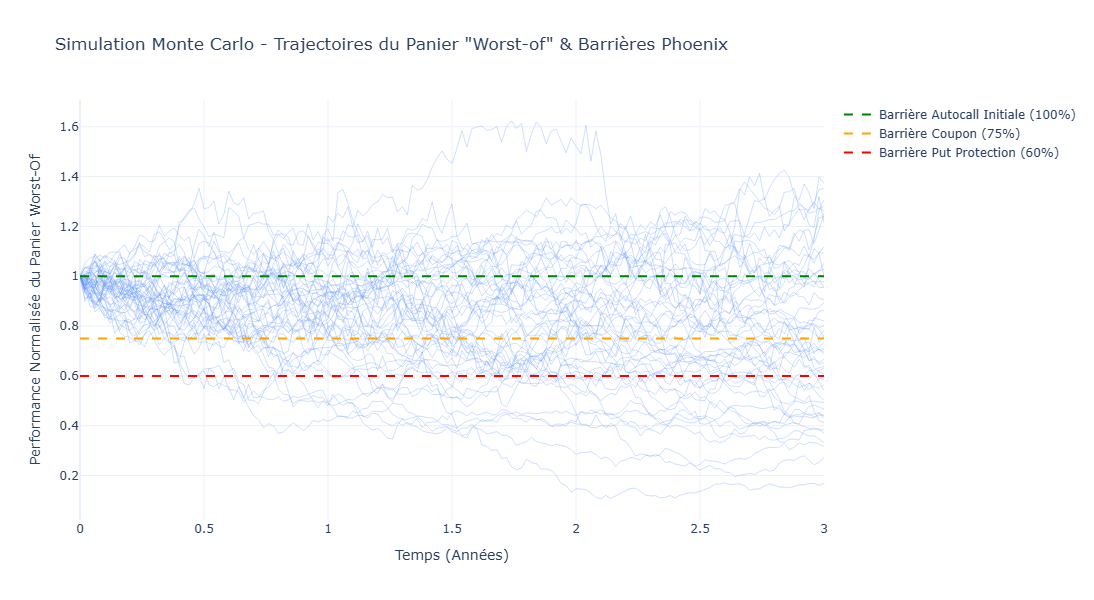

In [9]:
# Génération d'un échantillon de trajectoires pour la visualisation
S_paths_sample, _ = generate_multivariate_heston_paths(
    S0, V0, r, q, kappa, theta, xi, rho, corr_matrix, T, n_steps, 50
)

# Calcul du worst-of pour chaque trajectoire échantillonnée
worst_paths = np.min(S_paths_sample / S0[np.newaxis, np.newaxis, :], axis=2)
time_grid = np.linspace(0, T, n_steps + 1)

fig = go.Figure()

# Tracer quelques chemins du Worst-of
for i in range(50):
    fig.add_trace(go.Scatter(
        x=time_grid, y=worst_paths[i],
        mode='lines', line=dict(width=1, color='rgba(100, 150, 250, 0.3)'),
        showlegend=False
    ))

# Ajouter les barrières de rappel et de coupon
fig.add_trace(go.Scatter(
    x=time_grid, y=np.ones_like(time_grid) * 1.0,
    mode='lines', line=dict(color='green', dash='dash', width=2),
    name='Barrière Autocall Initiale (100%)'
))

fig.add_trace(go.Scatter(
    x=time_grid, y=np.ones_like(time_grid) * 0.75,
    mode='lines', line=dict(color='orange', dash='dash', width=2),
    name='Barrière Coupon (75%)'
))

fig.add_trace(go.Scatter(
    x=time_grid, y=np.ones_like(time_grid) * 0.60,
    mode='lines', line=dict(color='red', dash='dash', width=2),
    name='Barrière Put Protection (60%)'
))

fig.update_layout(
    title='Simulation Monte Carlo - Trajectoires du Panier "Worst-of" & Barrières Phoenix',
    xaxis_title='Temps (Années)',
    yaxis_title='Performance Normalisée du Panier Worst-Of',
    template='plotly_white',
    height=600
)

fig.show()

## Visualization of Simulated Worst-of Paths

This cell generates a small sample of 50 Heston price trajectories to visualize the behavior of the Worst-of basket.

For each simulated path, the performance of each underlying is normalized by its initial level. The Worst-of performance is then defined as the minimum performance across the three assets at each point in time:

$$
W_t = \min_{i=1,\ldots,N}\left(\frac{S_t^i}{S_0^i}\right).
$$

This is the relevant quantity for the Phoenix Autocall because the product depends on the weakest-performing underlying. A path can therefore remain below the contractual barriers even if the other assets perform well.

The cell then plots the 50 simulated Worst-of trajectories together with the three main contractual levels: the initial 100% Autocall barrier, the 75% coupon barrier, and the 60% Down-and-In protection barrier. The horizontal axis represents time in years, while the vertical axis represents the normalized Worst-of performance.

The resulting chart provides an intuitive view of the path-dependent nature of the product. In particular, it shows how the Worst-of basket interacts with the different barriers throughout the life of the note and illustrates why the weakest underlying is the main driver of the product's risk.
